## Week 1 – Monthly Dataset Aggregation
Individual monthly files are combined into unified datasets that span multiple months, enabling trend
analysis over time. 

### Objective
Load and concatenate all monthly MLS files from January 2024 through the most recently completed
calendar month into analysis-ready combined datasets.

### Outputs
- Combined sold transactions dataset
- Combined listing data dataset

### Skills Learned
- Multi-file dataset management
- Data aggregation with Pandas
- Preparing time-series datasets for analysis


In [116]:
# This line just hides warning messages so we can focus on the results—but we only use it when we understand what those warnings mean.
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np
import glob
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Turn off scientific notation
pd.set_option('display.float_format', '{:.2f}'.format)

In [117]:
data_path = Path("/Users/sarahbarah3/Desktop/crmls")
save_path = Path("/Users/sarahbarah3/Desktop/crmls/combined")

In [118]:
def read_csv_with_fallback(filepath):
    """Read CSV with UTF-8, fallback to cp1252 if needed."""
    try:
        df = pd.read_csv(filepath, encoding="utf-8")
        return df, "utf-8"
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, encoding="cp1252")
        return df, "cp1252"

### Define lists

In [119]:
listing_files = list(data_path.glob("CRMLSListing*.csv"))
sold_files = list(data_path.glob("CRMLSSold*.csv"))

In [120]:
print(list(data_path.glob("*.csv")))

[PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSSold202404_filled.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSSold202409.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202405.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202411.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202410.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202404.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSSold202408.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202604.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202412.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202406.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202407.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/priceratio.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSSold202501_filled.csv'), PosixPath('/Users/sarahbarah3/Desktop/crmls/CRMLSListing202601.csv'), PosixPath('/Users/sarahba

### Read and Concatenate

In [121]:
# Load and combine multiple listing datasets with encoding fallback, while tracking file encodings and row counts
full_listing = []
encoding_log = []
row_counts = []

for filepath in listing_files:
    df, encoding_used = read_csv_with_fallback(filepath)

    full_listing.append(df)
    encoding_log.append((filepath, encoding_used))
    row_counts.append(len(df))

# Safety check before concat
if full_listing:
    listing_combined = pd.concat(full_listing, ignore_index=True)
    print("Combined listing shape:", listing_combined.shape)
else:
    print("No listing files were loaded.")

Combined listing shape: (890318, 84)


In [122]:
# Load and combine multiple sold datasets with encoding fallback, while tracking file encodings and row counts
full_sold = []
encoding_log_sold = []
row_counts_sold = []

for filepath in sold_files:
    df, encoding_used = read_csv_with_fallback(filepath)

    full_sold.append(df)
    encoding_log_sold.append((filepath, encoding_used))
    row_counts_sold.append(len(df))

if full_sold:
    sold_combined = pd.concat(full_sold, ignore_index=True)
    print("Combined sold shape:", sold_combined.shape)
else:
    print("No sold files were loaded.")

Combined sold shape: (682623, 84)


In [123]:
listing_combined.to_csv(save_path / "listing_combined.csv", index=False)
sold_combined.to_csv(save_path / "sold_combined.csv", index=False)

### View the first and last 5 rows of the listing dataset.

In [124]:
listing_combined.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,BuyerAgencyCompensationType,BuyerAgencyCompensation
0,929000.00,1076194146,dianne@drector.com,NaN,NaN,Dianne,Rector,NaN,NaN,16882 Canyon Lane,...,2.00,Huntington Beach Union High,92649,NaN,330.00,1847.00,NaN,16882 Canyon Lane,NaN,NaN
1,999999.00,1076194026,realestateby_denisegarcia@gmail.com,NaN,NaN,Denise,Garcia,NaN,NaN,8720 S 4th Avenue,...,2.00,Inglewood Unified,90305,NaN,0.00,8508.00,NaN,8720 S 4th Avenue,NaN,NaN
2,1400000.00,1076193814,alizabethjames@hotmail.com,NaN,NaN,Alizabeth,James,33.86,-116.54,505 E Molino Road,...,2.00,Palm Springs Unified,92262,NaN,NaN,10890.00,NaN,505 E Molino Road,NaN,NaN
3,4998888.00,1076193812,ernieramos62@yahoo.com,NaN,NaN,Ernesto,Ramos,NaN,NaN,3653 Halldale Avenue,...,0.00,NaN,90018,NaN,NaN,6192.00,NaN,3653 Halldale Avenue,NaN,NaN
4,549000.00,1076193525,parsanina@yahoo.com,NaN,NaN,Nina,Parsa,NaN,NaN,1736 N Mcdivitt Avenue,...,2.00,Los Angeles Unified,90221,NaN,0.00,4113.00,NaN,1736 N Mcdivitt Avenue,NaN,NaN


In [125]:
listing_combined.tail()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,BuyerAgencyCompensationType,BuyerAgencyCompensation
890313,25000.00,1061308992,robin@cbborrego.com,NaN,NaN,Robin,Reynolds,33.27,-115.95,1102 Stanford Avenue,...,NaN,NaN,92274,NaN,0.00,13503.60,NaN,1102 Stanford Avenue,NaN,NaN
890314,625000.00,1060129455,joel@ripfritzer.com,NaN,NaN,Joel,Cloud,32.77,-116.93,1725 Grove Road,...,NaN,NaN,92020,NaN,0.00,43560.00,NaN,1725 Grove Road,NaN,NaN
890315,409000.00,1058408504,marierealtor4you@gmail.com,NaN,NaN,Marie,Arredondo,33.21,-116.30,3135 Club Circle East,...,2.00,Borrego Springs Unified,92004,NaN,0.00,34848.00,NaN,3135 Club Circle East,NaN,NaN
890316,3900000.00,1038675566,brettbman@gmail.com,NaN,NaN,Brett,Baumann,37.50,-120.05,665 Acs. - Mt Bullion Cut-Off Road,...,NaN,NaN,95338,NaN,0.00,28980903.60,NaN,665 Acs. - Mt Bullion Cut-Off Road,NaN,NaN
890317,1825000.00,1038248402,taylor@willisallen.com,NaN,NaN,Taylor,Smith,32.62,-117.13,5 Bridgetown Bend,...,2.00,Coronado Unified,92118,NaN,331.00,3959.00,NaN,5 Bridgetown Bend,NaN,NaN


### View the first and last 5 rows of the sold dataset.

In [126]:
sold_combined.head()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,NaN,True,NaN,NaN,NaN,159000.00,555125771,deborah.potestio@c21selectgroup.com,2024-04-29,45000.00,...,95916,0.00,336283.20,NaN,False,False,NaN,NaN,NaN,NaN
1,NaN,True,NaN,NaN,NaN,144000.00,554271746,crchapman@sbcglobal.net,2024-04-26,78000.00,...,95966,0.00,101495.00,NaN,False,False,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,False,265000.00,543251400,michaelg@londonproperties.com,2024-04-02,250000.00,...,93726,0.00,8100.00,NaN,False,False,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,NaN,925000.00,539236677,chris.campbell@msn.com,2024-04-10,815000.00,...,92223,0.00,564988.00,NaN,False,False,NaN,NaN,NaN,NaN
4,NaN,True,NaN,NaN,NaN,25000.00,538449222,rrinder@sbcglobal.net,2024-04-06,15000.00,...,95966,0.00,6098.00,NaN,False,False,NaN,NaN,NaN,NaN


In [127]:
sold_combined.tail()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
682618,NaN,NaN,NaN,NaN,NaN,649000.00,1008475397,chiggamasta424@gmail.com,2024-04-22,450000.00,...,90805,NaN,4682.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
682619,NaN,True,NaN,NaN,NaN,75689.00,1003434877,jhisquierdo@lee-associates.com,2024-04-03,75689.00,...,92371,NaN,946123.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
682620,NaN,True,NaN,NaN,NaN,275000.00,1002713752,MLS@DaltonRealtors.com,2024-04-19,100000.00,...,92082,0.00,619859.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
682621,NaN,False,NaN,NaN,False,10000.00,1002447928,Tazzie@CoronadoPremierProperties.com,2024-04-05,8300.00,...,92118,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
682622,NaN,True,NaN,NaN,NaN,1600000.00,1001660596,diana@countryqueen.com,2024-04-03,1050000.00,...,91765,294.00,52212.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Overview of the dataset shape (Listing)

In [128]:
# checking the shape of the data
print(f"There are {listing_combined.shape[0]} rows and {listing_combined.shape[1]} columns in combined listing data.")  # f-string

There are 890318 rows and 84 columns in combined listing data.


### Overview of the dataset shape (Sold)

In [129]:
# checking the shape of the data
print(f"There are {sold_combined.shape[0]} rows and {sold_combined.shape[1]} columns in combined sold data.")  # f-string

There are 682623 rows and 84 columns in combined sold data.


### View Listing dataset columns

In [130]:
listing_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890318 entries, 0 to 890317
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             886870 non-null  float64
 1   ListingKey                    890318 non-null  int64  
 2   ListAgentEmail                817674 non-null  object 
 3   CloseDate                     271713 non-null  object 
 4   ClosePrice                    248210 non-null  float64
 5   ListAgentFirstName            885096 non-null  object 
 6   ListAgentLastName             890238 non-null  object 
 7   Latitude                      777935 non-null  float64
 8   Longitude                     778660 non-null  float64
 9   UnparsedAddress               887991 non-null  object 
 10  PropertyType                  890318 non-null  object 
 11  LivingArea                    779709 non-null  float64
 12  ListPrice                     888105 non-nul

### View Sold dataset columns

In [131]:
sold_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682623 entries, 0 to 682622
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      400379 non-null  object 
 1   ViewYN                        614533 non-null  object 
 2   WaterfrontYN                  377 non-null     object 
 3   BasementYN                    11178 non-null   object 
 4   PoolPrivateYN                 596162 non-null  object 
 5   OriginalListPrice             680625 non-null  float64
 6   ListingKey                    682623 non-null  int64  
 7   ListAgentEmail                638470 non-null  object 
 8   CloseDate                     682623 non-null  object 
 9   ClosePrice                    682616 non-null  float64
 10  ListAgentFirstName            678576 non-null  object 
 11  ListAgentLastName             682551 non-null  object 
 12  Latitude                      663030 non-nul

### Removing Duplicates

In [132]:
# Removing Duplicates (Listing)
# Sort columns
listing_clean = listing_combined[sorted(listing_combined.columns)]

# Remove .1 columns
listing_clean = listing_clean.loc[
    :, ~listing_clean.columns.str.endswith(".1")
]

# Remove duplicate column names
listing_clean = listing_clean.loc[
    :, ~listing_clean.columns.duplicated()
]

listing_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890318 entries, 0 to 890317
Data columns (total 73 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   AboveGradeFinishedArea        0 non-null       float64
 1   AssociationFee                603289 non-null  float64
 2   AssociationFeeFrequency       258002 non-null  object 
 3   AttachedGarageYN              587461 non-null  object 
 4   BathroomsTotalInteger         817519 non-null  float64
 5   BedroomsTotal                 783251 non-null  float64
 6   BelowGradeFinishedArea        3615 non-null    float64
 7   BuilderName                   30504 non-null   object 
 8   BuildingAreaTotal             142511 non-null  float64
 9   BusinessType                  6231 non-null    object 
 10  BuyerAgencyCompensation       123519 non-null  float64
 11  BuyerAgencyCompensationType   123538 non-null  object 
 12  BuyerAgentFirstName           262579 non-nul

In [133]:
# Removing Duplicates (Sold)
# Sort columns
sold_clean = sold_combined[sorted(sold_combined.columns)]

# Remove .1 columns
sold_clean = sold_clean.loc[
    :, ~sold_clean.columns.str.endswith(".1")
]

# Remove duplicate column names
sold_clean = sold_clean.loc[
    :, ~sold_clean.columns.duplicated()
]

# Final check
sold_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682623 entries, 0 to 682622
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   AboveGradeFinishedArea        0 non-null       float64
 1   AssociationFee                471215 non-null  float64
 2   AssociationFeeFrequency       202335 non-null  object 
 3   AttachedGarageYN              493262 non-null  object 
 4   BasementYN                    11178 non-null   object 
 5   BathroomsTotalInteger         650767 non-null  float64
 6   BedroomsTotal                 636824 non-null  float64
 7   BelowGradeFinishedArea        2946 non-null    float64
 8   BuilderName                   26166 non-null   object 
 9   BuildingAreaTotal             88136 non-null   float64
 10  BusinessType                  1896 non-null    object 
 11  BuyerAgencyCompensation       133596 non-null  float64
 12  BuyerAgencyCompensationType   133531 non-nul

### View column counts (Listing)

In [134]:
listing_clean.PropertyType.value_counts()

PropertyType
Residential            565703
ResidentialLease       184505
Land                    58435
ResidentialIncome       33043
ManufacturedInPark      25570
CommercialSale          12163
CommercialLease          8047
BusinessOpportunity      2852
Name: count, dtype: int64

### View column counts (Sold)

In [135]:
sold_clean.PropertyType.value_counts()

PropertyType
Residential            458866
ResidentialLease       155868
Land                    22633
ManufacturedInPark      18635
ResidentialIncome       18258
CommercialSale           4283
CommercialLease          3607
BusinessOpportunity       473
Name: count, dtype: int64

### Filter PropertyType to Residential only
We’re filtering the dataset to only include residential properties so we can analyze the deals that actually matter to us.

### Create new datasets

In [136]:
listing_residential_df = listing_clean[listing_clean["PropertyType"] == "Residential"]
sold_residential_df = sold_clean[sold_clean["PropertyType"] == "Residential"]

In [137]:
# Sanity Check
listing_residential_df["PropertyType"].unique()
sold_residential_df["PropertyType"].unique()

array(['Residential'], dtype=object)

### Show row and column counts after the Residential filter

In [138]:
# checking the shape of the data
print(f"There are {listing_residential_df.shape[0]} rows and {listing_residential_df.shape[1]} columns in listing data for residential only.")  # f-string
print(f"There are {sold_residential_df.shape[0]} rows and {sold_residential_df.shape[1]} columns in sold data for residential only.")  # f-string

There are 565703 rows and 73 columns in listing data for residential only.
There are 458866 rows and 84 columns in sold data for residential only.


In [139]:
print("Sold Residential:", sold_residential_df.shape)
print("Listing Residential:", listing_residential_df.shape)

Sold Residential: (458866, 84)
Listing Residential: (565703, 73)


### Save new datasets to CSVs (residential only)

In [140]:
listing_residential_df.to_csv(save_path / "listings_residential_properties.csv", index=False)
sold_residential_df.to_csv(save_path / "sold_residential_properties.csv", index=False)

## Week 2 – Data Structuring and Validation
Before analytics begins, the dataset must be inspected and filtered to ensure only relevant residential
property records are used.


### Listing

In [141]:
listing_residential_df.shape

(565703, 73)

In [142]:
listing_residential_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 565703 entries, 0 to 890317
Data columns (total 73 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   AboveGradeFinishedArea        0 non-null       float64
 1   AssociationFee                429788 non-null  float64
 2   AssociationFeeFrequency       242065 non-null  object 
 3   AttachedGarageYN              466876 non-null  object 
 4   BathroomsTotalInteger         565646 non-null  float64
 5   BedroomsTotal                 565551 non-null  float64
 6   BelowGradeFinishedArea        3212 non-null    float64
 7   BuilderName                   26289 non-null   object 
 8   BuildingAreaTotal             50282 non-null   float64
 9   BusinessType                  0 non-null       object 
 10  BuyerAgencyCompensation       78993 non-null   float64
 11  BuyerAgencyCompensationType   79013 non-null   object 
 12  BuyerAgentFirstName           164806 non-null  ob

In [143]:
# Null count + percentage summary
null_summary_listing = pd.DataFrame({
    "Null Count": listing_residential_df.isna().sum(),
    "Missing %": listing_residential_df.isna().mean() * 100
})

# Sort by highest missing %
null_summary_listing = null_summary_listing.sort_values(by="Missing %", ascending=False)

print(null_summary_listing.head(20))

                              Null Count  Missing %
AboveGradeFinishedArea            565703     100.00
FireplacesTotal                   565703     100.00
ElementarySchoolDistrict          565703     100.00
TaxYear                           565703     100.00
TaxAnnualAmount                   565703     100.00
MiddleOrJuniorSchoolDistrict      565703     100.00
BusinessType                      565703     100.00
CoveredSpaces                     565703     100.00
BelowGradeFinishedArea            562491      99.43
CoBuyerAgentFirstName             550634      97.34
BuilderName                       539414      95.35
LotSizeDimensions                 536142      94.77
BuildingAreaTotal                 515421      91.11
ElementarySchool                  498220      88.07
MiddleOrJuniorSchool              498144      88.06
BuyerAgencyCompensation           486710      86.04
BuyerAgencyCompensationType       486690      86.03
HighSchool                        477130      84.34
CoListAgentF

In [144]:
# Step 1: Calculate missing percentage
missing_listing = (
    listing_residential_df.isna()
    .mean()
    .mul(100)
    .to_frame(name="Missing %")
)

# Step 2: Flag columns >90% missing
missing_listing["Flag >90%"] = missing_listing["Missing %"] > 90

# Step 3: Filter flagged columns (optional)
high_missing_90_listing = missing_listing[missing_listing["Flag >90%"]]

print("Full Missing Summary (Listing):")
print(missing_listing.sort_values(by="Missing %", ascending=False))

print("\nColumns >90% missing:")
print(high_missing_90_listing)


Full Missing Summary (Listing):
                          Missing %  Flag >90%
AboveGradeFinishedArea       100.00       True
FireplacesTotal              100.00       True
ElementarySchoolDistrict     100.00       True
TaxYear                      100.00       True
TaxAnnualAmount              100.00       True
...                             ...        ...
ListingKey                     0.00      False
ListingId                      0.00      False
ListingContractDate            0.00      False
ListPrice                      0.00      False
DaysOnMarket                   0.00      False

[73 rows x 2 columns]

Columns >90% missing:
                              Missing %  Flag >90%
AboveGradeFinishedArea           100.00       True
BelowGradeFinishedArea            99.43       True
BuilderName                       95.35       True
BuildingAreaTotal                 91.11       True
BusinessType                     100.00       True
CoBuyerAgentFirstName             97.34       True
C

### Separate market analysis fields from metadata fields (Listing)

In [145]:
# Metadata fields
metadata_cols_list = [
    # IDs / system fields
    "ListingKey", "ListingKeyNumeric", "ListingId",

    # Agent info
    "ListAgentFirstName", "ListAgentLastName", "ListAgentFullName",
    "ListAgentEmail", "CoListAgentFirstName", "CoListAgentLastName",
    "BuyerAgentFirstName", "BuyerAgentLastName", "BuyerAgentMlsId",
    "CoBuyerAgentFirstName",

    # Office info
    "ListOfficeName", "BuyerOfficeName", "BuyerOfficeAOR", "CoListOfficeName",

    # Compensation
    "BuyerAgencyCompensation", "BuyerAgencyCompensationType",

    # Builder / misc
    "BuilderName", "BusinessType"
]

# Dropping Metadata Fields
listing_residential_df = listing_residential_df.drop(
    columns=metadata_cols_list,
    errors="ignore"
)

In [146]:
#  Market Analysis Fields
market_fields_listing = [
    # Pricing
    "ListPrice", "OriginalListPrice",

    # Time / activity
    "DaysOnMarket", "ListingContractDate", "ContractStatusChangeDate",

    # Property characteristics
    "LivingArea", "BuildingAreaTotal",
    "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeAcres", "LotSizeSquareFeet",
    "YearBuilt", "Stories", "Levels",
    "GarageSpaces", "ParkingTotal",
    "FireplacesTotal", "FireplaceYN",
    "NewConstructionYN", "AttachedGarageYN",
    "CoveredSpaces", "MainLevelBedrooms",

    # Location
    "City", "CountyOrParish", "PostalCode",
    "StateOrProvince", "Latitude", "Longitude",
    "UnparsedAddress", "SubdivisionName", "MLSAreaMajor",

    # Property classification
    "PropertyType", "PropertySubType", "MlsStatus",

    # School / neighborhood
    "ElementarySchool", "MiddleOrJuniorSchool", "HighSchool",
    "ElementarySchoolDistrict", "MiddleOrJuniorSchoolDistrict", "HighSchoolDistrict"
]

# Drop everything but these
listing_market_df = listing_residential_df[
    [col for col in market_fields_listing if col in listing_residential_df.columns]
]

### Retained Columns (Listing)

In [147]:
# Dropping School / neighborhood fields (for now)
pertinent_cols_listing = [
    # Pricing
    "ListPrice", "OriginalListPrice",

    # Time / activity
    "DaysOnMarket", "ListingContractDate", "ContractStatusChangeDate",

    # Property characteristics
    "LivingArea", "BuildingAreaTotal",
    "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeAcres", "LotSizeSquareFeet",
    "YearBuilt", "Stories", "Levels",
    "GarageSpaces", "ParkingTotal",
    "FireplacesTotal", "FireplaceYN",
    "NewConstructionYN", "AttachedGarageYN",
    "CoveredSpaces", "MainLevelBedrooms",

    # Location (VERY important)
    "City", "CountyOrParish", "PostalCode",
    "StateOrProvince", "Latitude", "Longitude",
    "UnparsedAddress", "SubdivisionName", "MLSAreaMajor",

    # Property classification
    "PropertyType", "PropertySubType", "MlsStatus"
]

# Final Cleaning
listing_final = listing_residential_df[
    [col for col in pertinent_cols_listing if col in listing_residential_df.columns]
]

### Sold

In [148]:
sold_residential_df.shape

(458866, 84)

In [149]:
sold_residential_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 458866 entries, 2 to 682617
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   AboveGradeFinishedArea        0 non-null       float64
 1   AssociationFee                353883 non-null  float64
 2   AssociationFeeFrequency       191535 non-null  object 
 3   AttachedGarageYN              388774 non-null  object 
 4   BasementYN                    8900 non-null    object 
 5   BathroomsTotalInteger         458786 non-null  float64
 6   BedroomsTotal                 458854 non-null  float64
 7   BelowGradeFinishedArea        2595 non-null    float64
 8   BuilderName                   22643 non-null   object 
 9   BuildingAreaTotal             32034 non-null   float64
 10  BusinessType                  0 non-null       object 
 11  BuyerAgencyCompensation       90381 non-null   float64
 12  BuyerAgencyCompensationType   90403 non-null   ob

In [150]:
# Null count + percentage summary
null_summary_sold = pd.DataFrame({
    "Null Count": sold_residential_df.isna().sum(),
    "Missing %": sold_residential_df.isna().mean() * 100
})

# Sort by highest missing %
null_summary_sold = null_summary_sold.sort_values(by="Missing %", ascending=False)

print(null_summary_sold)

                              Null Count  Missing %
AboveGradeFinishedArea            458866     100.00
ElementarySchoolDistrict          458866     100.00
MiddleOrJuniorSchoolDistrict      458866     100.00
TaxYear                           458866     100.00
TaxAnnualAmount                   458866     100.00
...                                  ...        ...
CloseDate                              0       0.00
ListingId                              0       0.00
ListingKey                             0       0.00
DaysOnMarket                           0       0.00
CountyOrParish                         0       0.00

[84 rows x 2 columns]


In [151]:
# Step 1: Calculate missing percentage
missing_sold = (
    sold_residential_df.isna()
    .mean()
    .mul(100)
    .to_frame(name="Missing %")
)

# Step 2: Flag columns >90% missing
missing_sold["Flag >90%"] = missing_sold["Missing %"] > 90

# Step 3: Filter flagged columns (optional)
high_missing_90_sold = missing_sold[missing_sold["Flag >90%"]]

print("Full Missing Summary (Sold):")
print(missing_sold.sort_values(by="Missing %", ascending=False))

print("\nColumns >90% missing:")
print(high_missing_90_sold)

Full Missing Summary (Sold):
                              Missing %  Flag >90%
AboveGradeFinishedArea           100.00       True
ElementarySchoolDistrict         100.00       True
MiddleOrJuniorSchoolDistrict     100.00       True
TaxYear                          100.00       True
TaxAnnualAmount                  100.00       True
...                                 ...        ...
CloseDate                          0.00      False
ListingId                          0.00      False
ListingKey                         0.00      False
DaysOnMarket                       0.00      False
CountyOrParish                     0.00      False

[84 rows x 2 columns]

Columns >90% missing:
                              Missing %  Flag >90%
AboveGradeFinishedArea           100.00       True
BasementYN                        98.06       True
BelowGradeFinishedArea            99.43       True
BuilderName                       95.07       True
BuildingAreaTotal                 93.02       True
Busines

### Separate market analysis fields from metadata fields (Sold)

In [152]:
# Metadata Fields
metadata_cols_sold = [
    # IDs / system
    "ListingKey", "ListingKeyNumeric", "ListingId",

    # Agent info
    "ListAgentFirstName", "ListAgentLastName", "ListAgentFullName",
    "ListAgentEmail", "CoListAgentFirstName", "CoListAgentLastName",
    "BuyerAgentFirstName", "BuyerAgentLastName", "BuyerAgentMlsId",
    "CoBuyerAgentFirstName",

    # Office info
    "ListOfficeName", "BuyerOfficeName", "BuyerOfficeAOR", "CoListOfficeName",

    # Compensation
    "BuyerAgencyCompensation", "BuyerAgencyCompensationType",

    # Builder / misc
    "BuilderName", "BusinessType"
]

# Dropping Metadata Fields
sold_residential_df = sold_residential_df.drop(
    columns=metadata_cols_sold,
    errors="ignore"
)


In [153]:
# Market Data Analysis (Sold)
market_fields_sold = [
    # Pricing (MOST IMPORTANT)
    "ClosePrice", "ListPrice", "OriginalListPrice",

    # Time / transaction
    "CloseDate", "PurchaseContractDate",
    "ListingContractDate", "ContractStatusChangeDate",
    "DaysOnMarket",

    # Property characteristics
    "LivingArea", "BuildingAreaTotal",
    "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeAcres", "LotSizeSquareFeet",
    "YearBuilt", "Stories", "Levels",
    "GarageSpaces", "ParkingTotal",
    "FireplacesTotal", "FireplaceYN",
    "NewConstructionYN", "AttachedGarageYN",
    "CoveredSpaces", "MainLevelBedrooms",
    "AboveGradeFinishedArea", "BelowGradeFinishedArea",

    # Location (CRITICAL)
    "City", "CountyOrParish", "PostalCode",
    "StateOrProvince", "Latitude", "Longitude",
    "UnparsedAddress", "SubdivisionName", "MLSAreaMajor",

    # Property classification
    "PropertyType", "PropertySubType", "MlsStatus",

    # School / neighborhood
    "ElementarySchool", "MiddleOrJuniorSchool", "HighSchool",
    "ElementarySchoolDistrict", "MiddleOrJuniorSchoolDistrict", "HighSchoolDistrict"
]

# Keep one these
sold_market_df = sold_residential_df[
    [col for col in market_fields_sold if col in sold_residential_df.columns]
]

### Retained Columns (Sold)

In [154]:
# Dropping School / neighborhood fields (for now)
pertinent_cols_sold = [
    # Pricing (MOST IMPORTANT)
    "ClosePrice", "ListPrice", "OriginalListPrice",

    # Time / transaction
    "CloseDate", "PurchaseContractDate",
    "ListingContractDate", "ContractStatusChangeDate",
    "DaysOnMarket",

    # Property characteristics
    "LivingArea", "BuildingAreaTotal",
    "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeAcres", "LotSizeSquareFeet",
    "YearBuilt", "Stories", "Levels",
    "GarageSpaces", "ParkingTotal",
    "FireplacesTotal", "FireplaceYN",
    "NewConstructionYN", "AttachedGarageYN",
    "CoveredSpaces", "MainLevelBedrooms",
    "AboveGradeFinishedArea", "BelowGradeFinishedArea",

    # Location (CRITICAL)
    "City", "CountyOrParish", "PostalCode",
    "StateOrProvince", "Latitude", "Longitude",
    "UnparsedAddress", "SubdivisionName", "MLSAreaMajor",

    # Property classification
    "PropertyType", "PropertySubType", "MlsStatus"
]
# Final Cleaning
sold_final = sold_residential_df[
    [col for col in pertinent_cols_sold if col in sold_residential_df.columns]
]

### Numeric Distribution Review
Analyze the distribution of key numeric fields: ClosePrice, ListPrice, OriginalListPrice, LivingArea, LotSizeAcres, BedroomsTotal, BathroomsTotalInteger, DaysOnMarket, and YearBuilt. For each field, generate histograms, boxplots, and percentile summaries, and identify extreme outliers for later handling.

In [155]:
numeric_cols = [
    "ClosePrice", "ListPrice", "OriginalListPrice",
    "LivingArea", "LotSizeAcres",   
    "BedroomsTotal", "BathroomsTotalInteger",
    "DaysOnMarket", "YearBuilt"
]

### Number Distribution Summary

In [156]:
# Percentile Summaries
summary = []

for col in numeric_cols:
    data = sold_final[col].dropna()
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower) | (data > upper)]
    
    summary.append({
        "Column": col,
        "Mean": data.mean(),
        "Median": data.median(),
        "Min": data.min(),
        "Max": data.max(),
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outliers (#)": len(outliers), 
        "Outliers (%)": round(len(outliers)/len(data)*100, 2)
    })

summary_df = pd.DataFrame(summary)
summary_df

,Column,Mean,Median,Min,Max,Lower Bound,Upper Bound,Outliers (#),Outliers (%)
0,ClosePrice,1180965.38,820000.00,0.00,989500000.00,-512500.00,2387500.00,33981,7.41
1,ListPrice,1136903.93,810000.00,525.00,137500000.00,-497500.00,2362500.00,34281,7.47
2,OriginalListPrice,1216167.71,825000.00,0.00,1390000000.00,-486000.00,2370000.00,35542,7.76
3,LivingArea,1897.98,1640.00,0.00,17021321.00,-208.62,3672.38,20177,4.40
4,LotSizeAcres,80.12,0.17,0.00,7810698.36,-0.11,0.50,65850,15.59
5,BedroomsTotal,3.20,3.00,0.00,45.00,1.50,5.50,25289,5.51
6,BathroomsTotalInteger,2.53,2.00,0.00,175.00,0.50,4.50,21023,4.58
7,DaysOnMarket,36.92,18.00,-288.00,12430.00,-52.00,108.00,34850,7.59
8,YearBuilt,1978.63,1979.00,1776.00,2026.00,1901.50,2057.50,1061,0.23


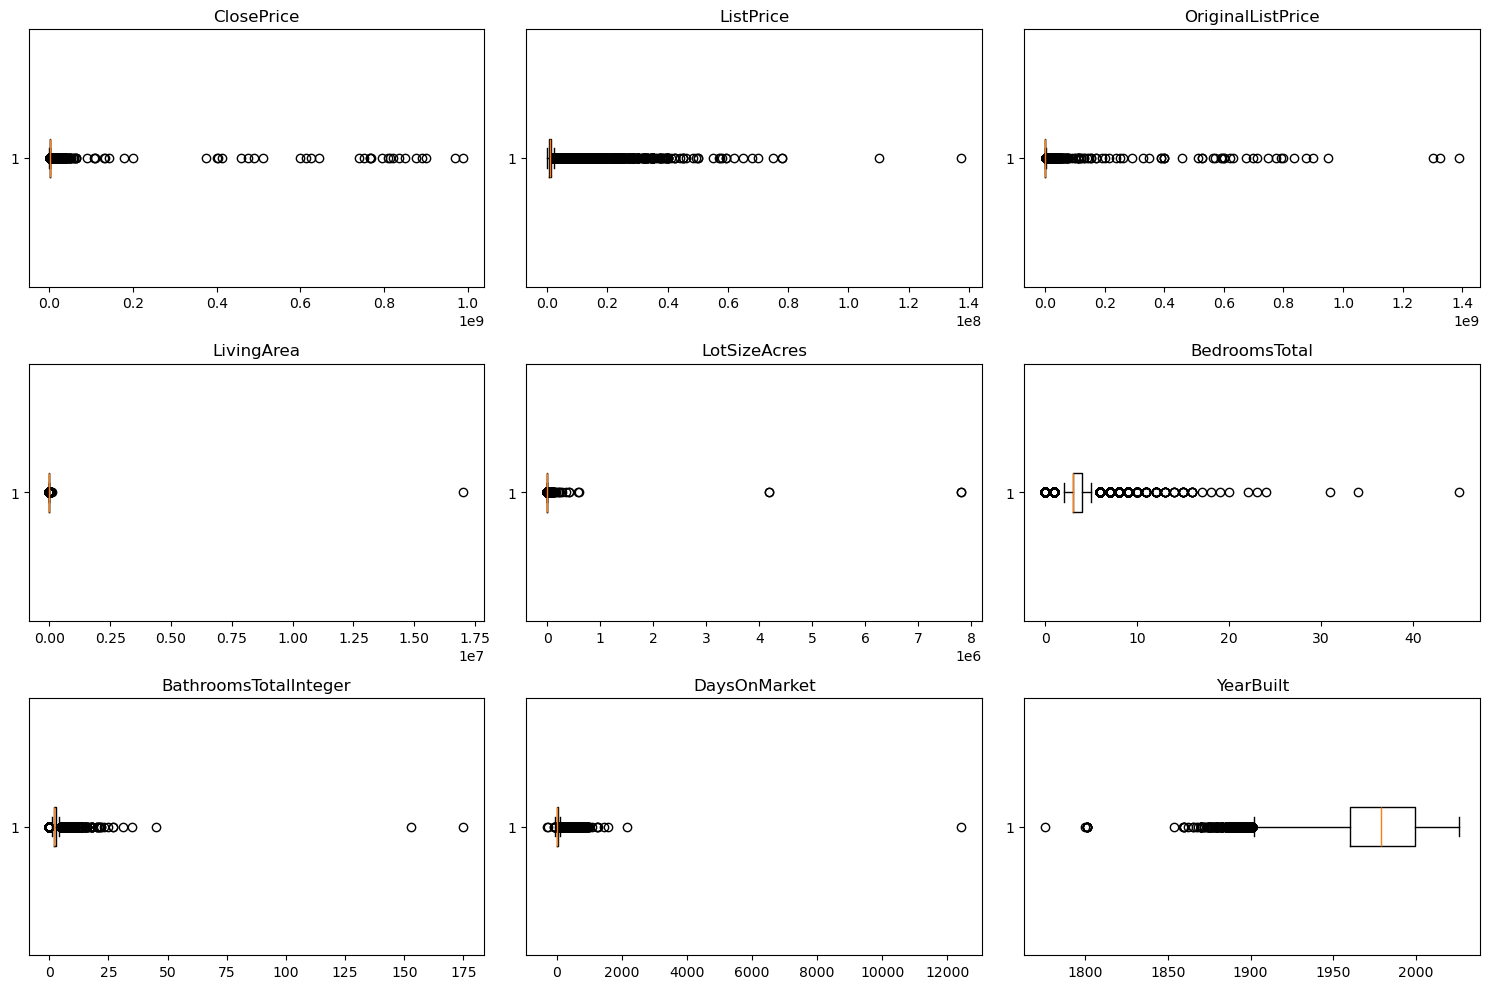

In [157]:
# Boxplots for numeric columns
n = len(numeric_cols)

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)  # adjust grid if needed
    plt.boxplot(sold_final[col].dropna(), vert=False)
    plt.title(col)

plt.tight_layout()
plt.show()

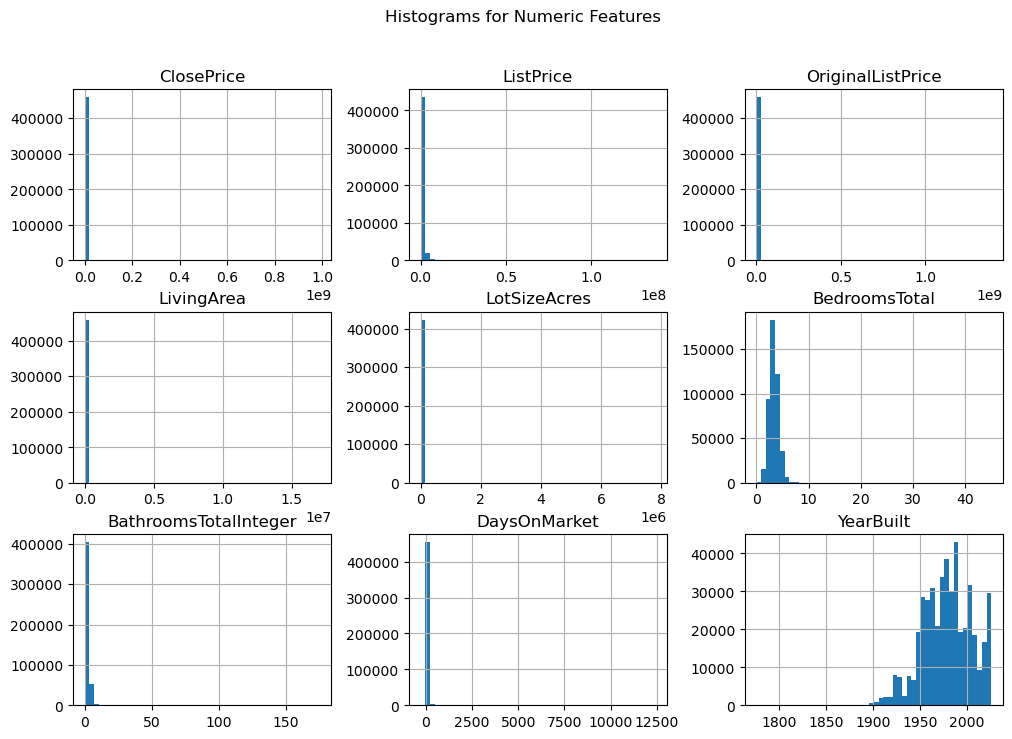

In [158]:
# Combined histograms in grid
sold_final[numeric_cols].hist(bins=50, figsize=(12, 8))
plt.suptitle("Histograms for Numeric Features")
plt.show()

### Identify extreme outliers (IQR Method)

In [159]:
outliers_dict = {}

for col in numeric_cols:
    if col in sold_final.columns:
        data = sold_final[col].dropna()

        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = data[(data < lower_bound) | (data > upper_bound)]

        outliers_dict[col] = len(outliers)

        print(f"{col}: {len(outliers)} outliers")

ClosePrice: 33981 outliers
ListPrice: 34281 outliers
OriginalListPrice: 35542 outliers
LivingArea: 20177 outliers
LotSizeAcres: 65850 outliers
BedroomsTotal: 25289 outliers
BathroomsTotalInteger: 21023 outliers
DaysOnMarket: 34850 outliers
YearBuilt: 1061 outliers


In [160]:
# Removed Unrealistic Outliers
# Define thresholds based on domain knowledge and summary statistics
thresholds = {
    "LivingArea": 10_000,      # Remove properties larger than 10,000 sqft
    "LotSizeAcres": 5,         # Remove properties with lot size larger than 5 acres
    "BedroomsTotal": 10,       # Remove properties with more than 10 bedrooms
    "BathroomsTotalInteger": 10, # Remove properties with more than 10 bathrooms
    "DaysOnMarket": 365,       # Remove properties that were on the market for more than 1 year
}

# Will remove ClosePrice outliers later, after we analyze the distribution more closely

### Key Takeaways
- Data is heavily right-skewed → median is a better measure than mean
- ClosePrice: Influenced by high-value outliers (luxury homes) → inflates mean
- LivingArea: Contains unrealistic max values → possible data quality issues
- LotSize: Extreme outlier skewing distribution → may need removal or validation
- DaysOnMarket: Includes negative and unusually high values → likely data errors

Overall, these patterns are expected in real estate data, but outliers and invalid values should be handled carefully before analysis.

### Suggested Intern Questions

In [161]:
# Q1. What is the Residential vs. other property type share?
property_summary = (
    listing_final['PropertyType']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print(property_summary)

PropertyType
Residential   100.00
Name: proportion, dtype: float64


In [162]:
# sanity check to make sure all are residential
listing_final["PropertyType"].value_counts()

PropertyType
Residential    565703
Name: count, dtype: int64

In [163]:
# Q2. What are the median and average close prices?
median_price = round(sold_final['ClosePrice'].median(), 2)
mean_price = round(sold_final['ClosePrice'].mean(), 2)

print("Median Close Price:", median_price)
print("Average Close Price:", mean_price)

Median Close Price: 820000.0
Average Close Price: 1180965.38


- Average is much higher than median, indicating a right-skewed distribution with some high-end outliers
- The large gap between mean and median suggests the presence of high-end properties, 
- Reinforcing the need for outlier analysis or segmentation when modeling price trends.

In [164]:
# IQR method for outlier detection on ClosePrice
Q1 = sold_final["ClosePrice"].quantile(0.25)
Q3 = sold_final["ClosePrice"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Identify outliers
outliers = sold_final[
    (sold_final["ClosePrice"] < lower_bound) |
    (sold_final["ClosePrice"] > upper_bound)
]

print("Number of outliers:", outliers.shape[0])

# Outliers removed
sold_finalQ2 = sold_final[
    (sold_final["ClosePrice"] >= lower_bound) &
    (sold_final["ClosePrice"] <= upper_bound)
].copy()

Lower Bound: -512500.0
Upper Bound: 2387500.0
Number of outliers: 33981


- Anything over 2387500.0 are outliers, best to remove them
- 32609 homes are considered outliers which is ~7.37% of the dataset
- Not random and definitely due to luxury homes
- Extreme outliers were removed

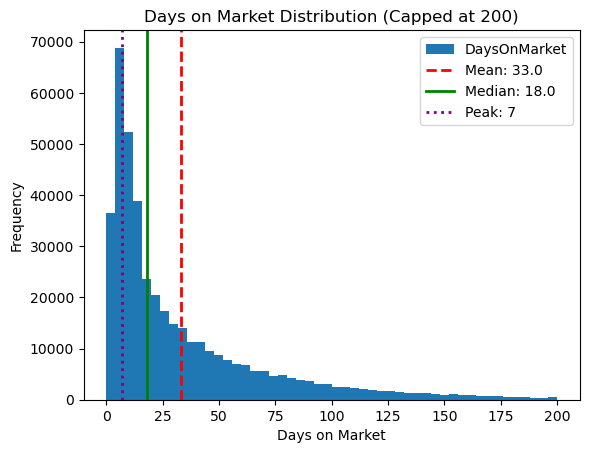

In [165]:
# Q3. Histogram of Days on Market with mean, median, and peak labels
sold_finalQ3 = sold_finalQ2[
    (sold_finalQ2["DaysOnMarket"] >= 0) &
    (sold_finalQ2["DaysOnMarket"] <= 200)
]

mean = sold_finalQ3["DaysOnMarket"].mean()
median = sold_finalQ3["DaysOnMarket"].median()
peak = sold_finalQ3["DaysOnMarket"].mode()[0]

sold_finalQ3['DaysOnMarket'].plot(kind='hist', bins=50)

plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {round(mean,1)}')
plt.axvline(median, color='green', linestyle='-', linewidth=2, label=f'Median: {median}')
plt.axvline(peak, color='purple', linestyle=':', linewidth=2, label=f'Peak: {peak}')


plt.title("Days on Market Distribution (Capped at 200)")
plt.xlabel("Days on Market")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [166]:
sold_finalQ3['DaysOnMarket'].describe()

count   418710.00
mean        33.01
std         37.37
min          0.00
25%          7.00
50%         18.00
75%         45.00
max        200.00
Name: DaysOnMarket, dtype: float64

The distribution of Days on Market is right-skewed, with most properties selling within a relatively short time frame. The median is lower than the mean, indicating the presence of outliers where some properties remain on the market significantly longer.
- Most homes sell quickly
- A few take much longer thus a skew
- The market is not evenly distributed

In [167]:
# Q3. What percentage of homes sold above vs. below list price?

sold_finalQ3['Above_List'] = sold_finalQ3['ClosePrice'] > sold_finalQ3['ListPrice']

# calculate the percentage of homes sold above vs. below list price
price_comparison = sold_finalQ3['Above_List'].value_counts(normalize=True) * 100

print(price_comparison)

# ~41% of homes sold above list price, while ~58% sold at or below list price.

Above_List
False   58.39
True    41.61
Name: proportion, dtype: float64


- ~42% of homes sold above list price |||| ~58% sold at or below list price
- Most homes are selling at or below asking
- So sellers aren't always getting bidding wars
- Market is not extremely overheated

- 41% is still high: indicates a strong demand in certain segments and competitive pockets of market

In [168]:
# Q4. Are there any apparent date consistency issues (e.g., close date before listing date)?

# We can check for date consistency by comparing the 'CloseDate' and 'ListDate' columns. If there are any rows where 'CloseDate' is before 'ListDate', that would indicate a potential issue.
sold_finalQ3['CloseDate'] = pd.to_datetime(sold_finalQ3['CloseDate'], errors='coerce')
sold_finalQ3['ListingContractDate'] = pd.to_datetime(sold_finalQ3['ListingContractDate'], errors='coerce')

date_issues = sold_finalQ3[sold_finalQ3['CloseDate'] < sold_finalQ3['ListingContractDate']]

print("Number of inconsistent records:", len(date_issues))

Number of inconsistent records: 48


- 46 records that showed as sold before it was listed
- It is logically impossible and the inconsistency are small enough to say it is safe to remove them

In [169]:
# remove records with date inconsistencies (if any)
sold_finalQ4 = sold_finalQ3[sold_finalQ3["CloseDate"] >= sold_finalQ3["ListingContractDate"]].copy()

In [170]:
date_issues[['ListingContractDate', 'CloseDate']].head()

,ListingContractDate,CloseDate
28878,2024-10-02,2024-09-19
29179,2024-09-30,2024-09-05
30015,2024-09-28,2024-09-24
70629,2025-01-24,2025-01-23
71358,2025-01-13,2025-01-10


In [171]:
# percentage (GOOD)
date_issue_percentage = (len(date_issues) / len(sold_finalQ4)) * 100
print(f"Percentage of date consistency issues: {date_issue_percentage:.2f}%")

Percentage of date consistency issues: 0.01%


In [172]:
# Which counties have the highest median prices?

# group by county, calculate median close price, and sort in descending order
county_median = (
    sold_finalQ4.groupby('CountyOrParish')['ClosePrice']
    .median()
    .sort_values(ascending=False)
)

print(county_median.head(10))

CountyOrParish
San Mateo       1374750.00
Santa Clara     1370000.00
San Francisco   1162500.00
Marin           1155000.00
Santa Cruz      1130000.00
Alameda         1085000.00
Orange          1075000.00
San Diego        860000.00
Los Angeles      857000.00
Ventura          850000.00
Name: ClosePrice, dtype: float64


In [173]:
# Table format for better readability
county_median_df = county_median.reset_index()
county_median_df.columns = ['County', 'Median Close Price']

print(county_median_df.head(10))

          County  Median Close Price
0      San Mateo          1374750.00
1    Santa Clara          1370000.00
2  San Francisco          1162500.00
3          Marin          1155000.00
4     Santa Cruz          1130000.00
5        Alameda          1085000.00
6         Orange          1075000.00
7      San Diego           860000.00
8    Los Angeles           857000.00
9        Ventura           850000.00


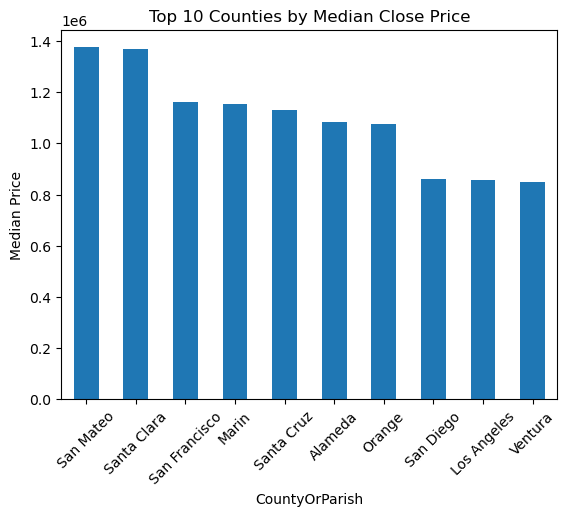

In [174]:
county_median.head(10).plot(kind='bar')
plt.title("Top 10 Counties by Median Close Price")
plt.ylabel("Median Price")
plt.xticks(rotation=45)
plt.show()

- Bay area dominates
    - high demand
    - tech industry
    - limited supply
- Coastal counties are expensive
- Key takeaway: location heavily impacts price

In [175]:
# Applying the thresholds to remove outliers from the sold_final dataset
sold_final2 = sold_finalQ4.copy()

for col, max_val in thresholds.items():
    sold_final2 = sold_final2[sold_final2[col] <= max_val]

In [176]:
# Sanity Check
print("Before:", sold_final.shape)
print("After:", sold_final2.shape)

Before: (458866, 39)
After: (372862, 40)


### Save the filtered dataset as a new CSV.

In [177]:
# Copying final cleaned datasets for export
sold_week2 = sold_finalQ4.copy()
listing_week2 = listing_final.copy()

# Save CSVs
sold_week2.to_csv("sold_week2.csv", index=False)
listing_week2.to_csv("listing_week2.csv", index=False)

### Final Key Takeaways
- Identified right-skewed distributions, especially in ClosePrice, due to high-value properties
- Compared mean vs. median to confirm the impact of luxury outliers
- Used the IQR method to detect and quantify outliers across numeric variables
- Removed unrealistic values using domain-based thresholds (e.g., extreme sizes, negative days)
- Retained meaningful outliers (e.g., luxury homes) to preserve market insights
- Created a cleaned dataset for more accurate and reliable analysis

### Tasks

In [178]:
# Inspect structure
sold_week2.columns

Index(['ClosePrice', 'ListPrice', 'OriginalListPrice', 'CloseDate',
       'PurchaseContractDate', 'ListingContractDate',
       'ContractStatusChangeDate', 'DaysOnMarket', 'LivingArea',
       'BuildingAreaTotal', 'BedroomsTotal', 'BathroomsTotalInteger',
       'LotSizeAcres', 'LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Levels',
       'GarageSpaces', 'ParkingTotal', 'FireplacesTotal', 'FireplaceYN',
       'NewConstructionYN', 'AttachedGarageYN', 'CoveredSpaces',
       'MainLevelBedrooms', 'AboveGradeFinishedArea', 'BelowGradeFinishedArea',
       'City', 'CountyOrParish', 'PostalCode', 'StateOrProvince', 'Latitude',
       'Longitude', 'UnparsedAddress', 'SubdivisionName', 'MLSAreaMajor',
       'PropertyType', 'PropertySubType', 'MlsStatus', 'Above_List'],
      dtype='object')

In [179]:
sold_week2.head()

,ClosePrice,ListPrice,OriginalListPrice,CloseDate,PurchaseContractDate,ListingContractDate,ContractStatusChangeDate,DaysOnMarket,LivingArea,BuildingAreaTotal,...,StateOrProvince,Latitude,Longitude,UnparsedAddress,SubdivisionName,MLSAreaMajor,PropertyType,PropertySubType,MlsStatus,Above_List
2,250000.00,265000.00,265000.00,2024-04-02,2022-09-08,2021-09-15,2024-04-02,68,1723.00,NaN,...,CA,36.78,-119.77,3533 Virginia Lane N,NaN,NaN,Residential,SingleFamilyResidence,Closed,False
7,413700.00,414999.00,429000.00,2024-04-30,2021-09-05,2021-05-12,2024-04-30,64,2285.00,NaN,...,CA,33.61,-116.47,68252 Materhorn,",IDK","326 - Pinyon Pines, Garner Valley",Residential,SingleFamilyResidence,Closed,False
25,600000.00,600000.00,600000.00,2024-04-12,2024-04-03,2024-02-15,2024-04-12,0,1600.00,NaN,...,CA,32.74,-116.99,3457 Kenora Dr,Spring Valley,91977 - Spring Valley,Residential,SingleFamilyResidence,Closed,False
26,600000.00,575000.00,575000.00,2024-04-08,2024-04-07,2024-04-07,2024-04-08,0,1726.00,NaN,...,CA,37.71,-122.42,312 Argonaut Ave,NaN,NaN,Residential,NaN,Closed,True
27,1810000.00,1695000.00,899999.00,2024-04-10,2024-03-19,2024-03-10,2024-04-10,9,2001.00,NaN,...,CA,37.84,-122.13,846 Crossbrook Ct,NaN,NaN,Residential,SingleFamilyResidence,Closed,True


In [180]:
# Check property categories
sold_week2['PropertyType'].unique()


array(['Residential'], dtype=object)

In [181]:
# Filter residential
sold_week2 = sold_week2[sold_week2.PropertyType == 'Residential']

In [182]:
# Validate completeness
sold_week2.isnull().sum()

ClosePrice                       0
ListPrice                        0
OriginalListPrice              608
CloseDate                        0
PurchaseContractDate           164
ListingContractDate              0
ContractStatusChangeDate      1147
DaysOnMarket                     0
LivingArea                     125
BuildingAreaTotal           393553
BedroomsTotal                   10
BathroomsTotalInteger           73
LotSizeAcres                 35036
LotSizeSquareFeet            34601
YearBuilt                      229
Stories                      58563
Levels                       36202
GarageSpaces                 15686
ParkingTotal                   826
FireplacesTotal             418661
FireplaceYN                    272
NewConstructionYN            31394
AttachedGarageYN             63447
CoveredSpaces               418661
MainLevelBedrooms           168703
AboveGradeFinishedArea      418661
BelowGradeFinishedArea      416287
City                           311
CountyOrParish      

## Week 3 - Mortgage Rate Enrichment
- Enrich both the combined sold and listings datasets by merging in the national 30-year fixed mortgage rate from the St. Louis Federal Reserve (FRED).

In [183]:
# Step 1 – Fetch mortgage data
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url, parse_dates=['observation_date'])
mortgage.columns = ['date', 'rate_30yr_fixed']

# Step 2 – Convert to monthly average
mortgage['year_month'] = mortgage['date'].dt.to_period('M')

mortgage_monthly = (
    mortgage.groupby('year_month')['rate_30yr_fixed']
    .mean()
    .reset_index()
)

# Step 3 – Create matching key in your datasets

# SOLD dataset
sold_week2['year_month'] = pd.to_datetime(
    sold_week2['CloseDate'], errors='coerce'
).dt.to_period('M')

# LISTING dataset
listing_week2['year_month'] = pd.to_datetime(
    listing_week2['ListingContractDate'], errors='coerce'
).dt.to_period('M')

# Step 4 – Merge
sold_with_rates = sold_week2.merge(
    mortgage_monthly, on='year_month', how='left'
)

listing_with_rates = listing_week2.merge(
    mortgage_monthly, on='year_month', how='left'
)

# Step 5 – Validate
print("Missing sold rates:", sold_with_rates['rate_30yr_fixed'].isnull().sum())
print("Missing listing rates:", listing_with_rates['rate_30yr_fixed'].isnull().sum())

# Preview
print(
    sold_with_rates[
        ['CloseDate', 'year_month', 'ClosePrice', 'rate_30yr_fixed']
    ].head()
)

Missing sold rates: 0
Missing listing rates: 0
   CloseDate year_month  ClosePrice  rate_30yr_fixed
0 2024-04-02    2024-04   250000.00             6.99
1 2024-04-30    2024-04   413700.00             6.99
2 2024-04-12    2024-04   600000.00             6.99
3 2024-04-08    2024-04   600000.00             6.99
4 2024-04-10    2024-04  1810000.00             6.99


In [184]:
# Save to CSV files

sold_with_rates.to_csv("sold_with_rates.csv", index=False)
listing_with_rates.to_csv("listing_with_rates.csv", index=False)

In [228]:
print("Sold with rates shape:", sold_with_rates.shape)
print("Listing with rates shape:", listing_with_rates.shape)

Sold with rates shape: (418661, 42)
Listing with rates shape: (565703, 36)


## Weeks 4–5 – Data Cleaning and Preparation
Raw MLS data contains formatting inconsistencies, missing values, and fields that need transformation before analysis. This phase prepares the dataset for reliable analytics.

Tasks
- Convert date fields to datetime format (CloseDate, PurchaseContractDate, ListingContractDate, ContractStatusChangeDate)
- Remove unnecessary or redundant columns (removed earlier)
- Handle missing values appropriately
- Ensure numeric fields are properly typed
- Remove or flag invalid numeric values: ClosePrice <= 0, LivingArea <= 0, DaysOnMarket < 0, negative Bedrooms or Bathrooms


### Convert to Datetime Format

In [186]:
sold_with_rates.columns

Index(['ClosePrice', 'ListPrice', 'OriginalListPrice', 'CloseDate',
       'PurchaseContractDate', 'ListingContractDate',
       'ContractStatusChangeDate', 'DaysOnMarket', 'LivingArea',
       'BuildingAreaTotal', 'BedroomsTotal', 'BathroomsTotalInteger',
       'LotSizeAcres', 'LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Levels',
       'GarageSpaces', 'ParkingTotal', 'FireplacesTotal', 'FireplaceYN',
       'NewConstructionYN', 'AttachedGarageYN', 'CoveredSpaces',
       'MainLevelBedrooms', 'AboveGradeFinishedArea', 'BelowGradeFinishedArea',
       'City', 'CountyOrParish', 'PostalCode', 'StateOrProvince', 'Latitude',
       'Longitude', 'UnparsedAddress', 'SubdivisionName', 'MLSAreaMajor',
       'PropertyType', 'PropertySubType', 'MlsStatus', 'Above_List',
       'year_month', 'rate_30yr_fixed'],
      dtype='object')

In [187]:
listing_with_rates.columns

Index(['ListPrice', 'OriginalListPrice', 'DaysOnMarket', 'ListingContractDate',
       'ContractStatusChangeDate', 'LivingArea', 'BuildingAreaTotal',
       'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres',
       'LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Levels', 'GarageSpaces',
       'ParkingTotal', 'FireplacesTotal', 'FireplaceYN', 'NewConstructionYN',
       'AttachedGarageYN', 'CoveredSpaces', 'MainLevelBedrooms', 'City',
       'CountyOrParish', 'PostalCode', 'StateOrProvince', 'Latitude',
       'Longitude', 'UnparsedAddress', 'SubdivisionName', 'MLSAreaMajor',
       'PropertyType', 'PropertySubType', 'MlsStatus', 'year_month',
       'rate_30yr_fixed'],
      dtype='object')

In [188]:
# Function to convert date columns with error handling
def convert_date_columns(df, date_cols):
    cols = [col for col in date_cols if col in df.columns]
    missing = [col for col in date_cols if col not in df.columns]
    
    if missing:
        print(f"Missing columns: {missing}")
    
    df[cols] = df[cols].apply(pd.to_datetime, errors='coerce')
    
    return df

In [189]:
# Create working copies
sold_clean = sold_with_rates.copy()
listing_clean = listing_with_rates.copy()

In [190]:
# Sold dates
date_cols_sold = [
    "CloseDate",
    "PurchaseContractDate",
    "ListingContractDate",
    "ContractStatusChangeDate"
]

# Listing dates
date_cols_listing = [
    "ListingContractDate",
    "ContractStatusChangeDate"
]

sold_clean = convert_date_columns(sold_clean, date_cols_sold)
listing_clean = convert_date_columns(listing_clean, date_cols_listing)

In [191]:
# Verify date conversion
sold_clean[date_cols_sold].dtypes
#listing_clean[date_cols_listing].dtypes

CloseDate                   datetime64[ns]
PurchaseContractDate        datetime64[ns]
ListingContractDate         datetime64[ns]
ContractStatusChangeDate    datetime64[ns]
dtype: object

### Remove unnecessary or redundant columns (removed earlier in Week 1)

In [192]:
# Sold
sold_missing = pd.DataFrame({
    "Missing Count": sold_clean.isna().sum()
})

sold_missing["Missing %"] = (
    sold_missing["Missing Count"] / len(sold_clean)
).round(2)

# Listing
listing_missing = pd.DataFrame({
    "Missing Count": listing_clean.isna().sum()
})

listing_missing["Missing %"] = (
    listing_missing["Missing Count"] / len(listing_clean)
).round(2)

### Handle missing values appropriately

In [193]:
from IPython.display import display, HTML

html = f"""
<div style="display: flex; gap: 40px;">
    <div>
        <h4>Sold Dataset</h4>
        {sold_missing[sold_missing["Missing Count"] > 0].to_html()}
    </div>
    <div>
        <h4>Listing Dataset</h4>
        {listing_missing[listing_missing["Missing Count"] > 0].to_html()}
    </div>
</div>
"""

display(HTML(html))

,Missing Count,Missing %
OriginalListPrice,608,0.00
PurchaseContractDate,164,0.00
ContractStatusChangeDate,1147,0.00
LivingArea,125,0.00
BuildingAreaTotal,393553,0.94
BedroomsTotal,10,0.00
BathroomsTotalInteger,73,0.00
LotSizeAcres,35036,0.08
LotSizeSquareFeet,34601,0.08
YearBuilt,229,0.00


In [194]:
# Missing summaries
sold_missing = pd.DataFrame({
    "Missing %": sold_clean.isna().mean()
})

listing_missing = pd.DataFrame({
    "Missing %": listing_clean.isna().mean()
})

# Drop columns >90% missing
sold_drop_cols = sold_missing[
    sold_missing["Missing %"] > 0.90
].index.tolist()

listing_drop_cols = listing_missing[
    listing_missing["Missing %"] > 0.90
].index.tolist()

# Manual drops
manual_drop_cols = ["SubdivisionName"]

# Drop columns
sold_clean = sold_clean.drop(
    columns=sold_drop_cols + manual_drop_cols,
    errors="ignore"
)

listing_clean = listing_clean.drop(
    columns=listing_drop_cols + manual_drop_cols,

    errors="ignore"
)

In [195]:
# Track Data Loss (SOLD)
before = len(sold_clean)

sold_clean = sold_clean[
    (sold_clean["ClosePrice"] > 0) &
    (sold_clean["LivingArea"] > 0) &
    (sold_clean["DaysOnMarket"] >= 0) &
    (sold_clean["BedroomsTotal"] >= 0) & # Assuming 0 bedrooms is possible (e.g., studio apartments)
    (sold_clean["BathroomsTotalInteger"] >= 0)
]

after = len(sold_clean)
print(f"Sold rows removed: {before - after}")


### SAFER APPROACH JUST IN CASE ONE OF THESE COLUMNS DOESN'T EXIST
required_cols_sold = [
    "ClosePrice", "LivingArea", "DaysOnMarket",
    "BedroomsTotal", "BathroomsTotalInteger"
]

sold_clean = sold_clean.dropna(subset=required_cols_sold)

print(f"Percent removed: {(before - after)/before:.2%}")

Sold rows removed: 283
Percent removed: 0.07%


In [196]:
# Track Data Loss (Listing)
before = len(listing_clean)

listing_clean = listing_clean[
    (listing_clean["OriginalListPrice"] > 0) &
    (listing_clean["LivingArea"] > 0) &
    (listing_clean["DaysOnMarket"] >= 0) &
    (listing_clean["BedroomsTotal"] >= 0) &
    (listing_clean["BathroomsTotalInteger"] >= 0)
]

after = len(listing_clean)

required_cols_listing = [
    "OriginalListPrice", "LivingArea", "DaysOnMarket",
    "BedroomsTotal", "BathroomsTotalInteger"
]

listing_clean = listing_clean.dropna(subset=required_cols_listing)

print(f"Listing rows removed: {before - after}")
print(f"Percent removed: {(before - after) / before:.2%}")

Listing rows removed: 1888
Percent removed: 0.33%


### Numeric Columns

In [197]:
# Define Numeric Columns
sold_numeric_cols = [
    "ClosePrice", "LivingArea", "DaysOnMarket",
    "BedroomsTotal", "BathroomsTotalInteger"
]

listing_numeric_cols = [
    "OriginalListPrice", "LivingArea", "DaysOnMarket",
    "BedroomsTotal", "BathroomsTotalInteger"
]

In [198]:
# Converts numeric columns, handles missing values, and applies validation rules to ensure data quality
def clean_numeric(df, numeric_cols, rules, name="dataset"):
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    before = len(df)

    df = df.dropna(subset=rules.keys())

    for col, condition in rules.items():
        df = df[condition(df[col])]

    after = len(df)
    print(f"{name}: removed {before - after} rows")

    return df


In [199]:
# Call function (more of a validaion step to ensure numeric columns are clean and meet expected criteria)
sold_rules = {
    "ClosePrice": lambda x: x > 0,
    "LivingArea": lambda x: x > 0,
    "DaysOnMarket": lambda x: x >= 0,
    "BedroomsTotal": lambda x: x >= 0,
    "BathroomsTotalInteger": lambda x: x >= 0  # MAYBE NEVER?
}

listing_rules = {
    "OriginalListPrice": lambda x: x > 0,
    "LivingArea": lambda x: x > 0,
    "DaysOnMarket": lambda x: x >= 0,
    "BedroomsTotal": lambda x: x >= 0,
    "BathroomsTotalInteger": lambda x: x >= 0
}

sold_clean = clean_numeric(sold_clean, sold_numeric_cols, sold_rules, "sold")
listing_clean = clean_numeric(listing_clean, listing_numeric_cols, listing_rules, "listing")

sold: removed 0 rows
listing: removed 0 rows


### Date Consistency Checks (Flags)

In [200]:
# Validate date consistency by flagging missing critical dates and invalid event timelines
def add_date_flags(df):
    
    # Missing critical dates
    date_cols = ["ListingContractDate", "PurchaseContractDate", "CloseDate"]
    existing_cols = [col for col in date_cols if col in df.columns]
    
    if existing_cols:
        df["missing_critical_dates_flag"] = df[existing_cols].isna().any(axis=1)

    # Listing after close
    if "ListingContractDate" in df.columns and "CloseDate" in df.columns:
        df["listing_after_close_flag"] = (
            df["ListingContractDate"].notna() &
            df["CloseDate"].notna() &
            (df["ListingContractDate"] > df["CloseDate"])
        )

    # Purchase after close
    if "PurchaseContractDate" in df.columns and "CloseDate" in df.columns:
        df["purchase_after_close_flag"] = (
            df["PurchaseContractDate"].notna() &
            df["CloseDate"].notna() &
            (df["PurchaseContractDate"] > df["CloseDate"])
        )

    # Negative timeline
    if "ListingContractDate" in df.columns and "PurchaseContractDate" in df.columns:
        df["negative_timeline_flag"] = (
            df["ListingContractDate"].notna() &
            df["PurchaseContractDate"].notna() &
            (df["ListingContractDate"] > df["PurchaseContractDate"])
        )

    return df

In [201]:
sold_clean = add_date_flags(sold_clean)
listing_clean = add_date_flags(listing_clean)

In [202]:
# Sanity Check
sold_clean.filter(like="flag").sum()

missing_critical_dates_flag    164
listing_after_close_flag         0
purchase_after_close_flag      216
negative_timeline_flag         183
dtype: int64

In [203]:
listing_clean.filter(like="flag").sum()

missing_critical_dates_flag    0
dtype: int64

### Numeric Consistency Checks

In [204]:
# Identify missing and invalid numeric values
# Sold
sold_clean["invalid_price_flag"] = (
    sold_clean["ClosePrice"].isna() | (sold_clean["ClosePrice"] <= 0)
)
sold_clean["invalid_area_flag"] = (
    sold_clean["LivingArea"].isna() | (sold_clean["LivingArea"] <= 0)
)
sold_clean["invalid_dom_flag"] = (
    sold_clean["DaysOnMarket"].isna() | (sold_clean["DaysOnMarket"] < 0)
)

# Listing
listing_clean["invalid_price_flag"] = (
    listing_clean["OriginalListPrice"].isna() | (listing_clean["OriginalListPrice"] <= 0)
)

listing_clean["invalid_area_flag"] = (
    listing_clean["LivingArea"].isna() | (listing_clean["LivingArea"] <= 0)
)

listing_clean["invalid_dom_flag"] = (
    listing_clean["DaysOnMarket"].isna() | (listing_clean["DaysOnMarket"] < 0)
)

### Geographic Data Checks

In [205]:
# Create flags to identify missing, invalid, and out-of-range geographic coordinates
def add_coordinate_flags(df, state_name="California"):
    df["missing_coord_flag"] = (
        df["Latitude"].isna() | df["Longitude"].isna()
    )

    df["zero_coord_flag"] = (
        (df["Latitude"] == 0) | (df["Longitude"] == 0)
    )

    df["positive_longitude_flag"] = (
        df["Longitude"] > 0
    )

    df["out_of_bounds_flag"] = (
        (df["Latitude"] < 32) | (df["Latitude"] > 42) |
        (df["Longitude"] < -125) | (df["Longitude"] > -114)
    )

    coord_flag_cols = [
        "missing_coord_flag",
        "zero_coord_flag",
        "positive_longitude_flag",
        "out_of_bounds_flag"
    ]

    df["any_coord_issue_flag"] = df[coord_flag_cols].any(axis=1)

    print(f"{state_name} coordinate issue counts:")
    print(df[coord_flag_cols].sum())

    return df

In [206]:
# Call the function for both datasets
sold_clean = add_coordinate_flags(sold_clean)
print("------------------------")
listing_clean = add_coordinate_flags(listing_clean)

California coordinate issue counts:
missing_coord_flag         14211
zero_coord_flag               24
positive_longitude_flag       32
out_of_bounds_flag            80
dtype: int64
------------------------
California coordinate issue counts:
missing_coord_flag         80142
zero_coord_flag               65
positive_longitude_flag       78
out_of_bounds_flag           281
dtype: int64


### Geographic Data Quality Summary
- A significant number of records have missing coordinates, which limits mapping and spatial analysis
- A small number of records contain (0,0) coordinates, likely placeholder or default values
- Some records show positive longitude values, which are invalid for California (should be negative)
- A subset of records fall outside expected California geographic bounds, indicating potential data entry or geocoding errors

Overall, most data is usable, but these flagged records may need to be removed or handled depending on analysis goals.

### Quick validation summary

In [207]:
# Define flags
date_flags = [
    "listing_after_close_flag",
    "purchase_after_close_flag",
    "negative_timeline_flag"
]

geo_flags = [
    "missing_coord_flag",
    "zero_coord_flag",
    "positive_longitude_flag",
    "out_of_bounds_flag"
]

numeric_flags = [
    "invalid_price_flag",
    "invalid_area_flag",
    "invalid_dom_flag"
]

all_flags = date_flags + geo_flags + numeric_flags

In [208]:
# Include percentages in the summary for better context on the prevalence of each issue
def summarize_flags(df, name):
    print(f"\n{name} Dataset Validation Summary")
    print("-" * 50)
    
    total = len(df)
    
    for col in all_flags:
        if col in df.columns:
            count = df[col].sum()
            pct = (count / total * 100) if total > 0 else 0
            print(f"{col}: {count} ({pct:.2f}%) flagged")

In [209]:
summarize_flags(sold_clean, "Sold")
summarize_flags(listing_clean, "Listing")


Sold Dataset Validation Summary
--------------------------------------------------
listing_after_close_flag: 0 (0.00%) flagged
purchase_after_close_flag: 216 (0.05%) flagged
negative_timeline_flag: 183 (0.04%) flagged
missing_coord_flag: 14211 (3.40%) flagged
zero_coord_flag: 24 (0.01%) flagged
positive_longitude_flag: 32 (0.01%) flagged
out_of_bounds_flag: 80 (0.02%) flagged
invalid_price_flag: 0 (0.00%) flagged
invalid_area_flag: 0 (0.00%) flagged
invalid_dom_flag: 0 (0.00%) flagged

Listing Dataset Validation Summary
--------------------------------------------------
missing_coord_flag: 80142 (14.21%) flagged
zero_coord_flag: 65 (0.01%) flagged
positive_longitude_flag: 78 (0.01%) flagged
out_of_bounds_flag: 281 (0.05%) flagged
invalid_price_flag: 0 (0.00%) flagged
invalid_area_flag: 0 (0.00%) flagged
invalid_dom_flag: 0 (0.00%) flagged


In [210]:
# Create a row-level data quality score by aggregating validation flags
def add_quality_metrics(df):
    flag_cols = [col for col in all_flags if col in df.columns]

    # Total issues per row
    df["total_issue_count"] = df[flag_cols].sum(axis=1)

    # Any issue flag
    df["any_issue_flag"] = df["total_issue_count"] > 0

    # Data quality score (1 = perfect, 0 = worst)
    if len(flag_cols) > 0:
        df["data_quality_score"] = 1 - (df["total_issue_count"] / len(flag_cols))
    else:
        df["data_quality_score"] = 1

    return df

In [211]:
# Add quality metrics to both datasets
sold_clean = add_quality_metrics(sold_clean)
listing_clean = add_quality_metrics(listing_clean)

In [212]:
# Add a quick summary function to report the number and percentage of rows with any issues, providing a clear overview of overall data quality
def summarize_group(df, flags, label):
    total = len(df)
    count = df[flags].any(axis=1).sum()
    pct = count / total * 100 if total > 0 else 0
    print(f"{label}: {count} rows ({pct:.2f}%) have issues")

In [213]:
def summarize_group(df, flags, label):
    existing_flags = [col for col in flags if col in df.columns]

    if len(existing_flags) == 0:
        print(f"{label}: No matching flags in this dataset")
        return

    total = len(df)
    count = df[existing_flags].any(axis=1).sum()
    pct = count / total * 100 if total > 0 else 0

    print(f"{label}: {count} rows ({pct:.2f}%) have issues")

In [214]:
summarize_group(sold_clean, date_flags, "Date Issues")
summarize_group(sold_clean, geo_flags, "Geo Issues")
summarize_group(sold_clean, numeric_flags, "Numeric Issues")

Date Issues: 399 rows (0.10%) have issues
Geo Issues: 14291 rows (3.42%) have issues
Numeric Issues: 0 rows (0.00%) have issues


In [215]:
summarize_group(listing_clean, date_flags, "Date Issues")
summarize_group(listing_clean, geo_flags, "Geo Issues")
summarize_group(listing_clean, numeric_flags, "Numeric Issues")

Date Issues: No matching flags in this dataset
Geo Issues: 80423 rows (14.26%) have issues
Numeric Issues: 0 rows (0.00%) have issues


In [216]:
print(sold_clean.dtypes)
print("------------------------")
print(listing_clean.dtypes)

ClosePrice                            float64
ListPrice                             float64
OriginalListPrice                     float64
CloseDate                      datetime64[ns]
PurchaseContractDate           datetime64[ns]
ListingContractDate            datetime64[ns]
ContractStatusChangeDate       datetime64[ns]
DaysOnMarket                            int64
LivingArea                            float64
BedroomsTotal                         float64
BathroomsTotalInteger                 float64
LotSizeAcres                          float64
LotSizeSquareFeet                     float64
YearBuilt                             float64
Stories                               float64
Levels                                 object
GarageSpaces                          float64
ParkingTotal                          float64
FireplaceYN                            object
NewConstructionYN                      object
AttachedGarageYN                       object
MainLevelBedrooms                 

### Data Transformation Summary
- Converted date fields to datetime format to support timeline validation
- Removed redundant and high-missing columns to improve data usability
- Standardized numeric fields and ensured proper data types
- Filtered invalid records (e.g., non-positive price, area, and negative days on market)
- Created date consistency flags to identify timeline issues across listing, purchase, and close dates (where applicable)
- Applied geographic validation to flag missing, invalid, and out-of-range coordinates

Overall, these transformations improved data quality, reduced noise, and ensured both datasets are clean and analysis-ready.

### Saved CSV for Week 4-5

In [217]:
sold_clean.to_csv("sold_week4_5.csv", index=False)
listing_clean.to_csv("listing_week4_5.csv", index=False)

In [218]:
print("Sold clean shape:", sold_clean.shape)
print("Listing clean shape:", listing_clean.shape)

Sold clean shape: (418378, 51)
Listing clean shape: (563815, 44)


## Weeks 6 – Feature Engineering and Market Metrics
### Key Metrics to Create

| Metric | Formula | Purpose |
|---|---|---|
| Price Ratio | `ClosePrice / OriginalListPrice` | Measures negotiation strength |
| Price Per Sq Ft | `ClosePrice / LivingArea` | Normalizes price across sizes |
| Days on Market | `DaysOnMarket` (raw field) | Time-to-sell indicator |
| Year / Month / YrMo | Derived from `CloseDate` | Enables time-series analysis |
| Close to Original List Ratio | `ClosePrice / OriginalListPrice` | Captures full price reduction history |
| Listing to Contract Days | `PurchaseContractDate - ListingContractDate` | Measures time from listing to accepted offer |
| Contract to Close Days | `CloseDate - PurchaseContractDate` | Escrow and closing period duration |

In [219]:
# Functions to create real estate metrics
def create_key_metrics(df):
    df = df.copy()

    # Convert date fields
    for col in ["CloseDate", "PurchaseContractDate", "ListingContractDate"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    # 1. Price Ratio: ClosePrice / OriginalListPrice
    if {"ClosePrice", "OriginalListPrice"}.issubset(df.columns):
        df["price_ratio"] = df["ClosePrice"] / df["OriginalListPrice"]

    # 2. Price Per Sq Ft: ClosePrice / LivingArea
    if {"ClosePrice", "LivingArea"}.issubset(df.columns):
        df["price_per_sqft"] = df["ClosePrice"] / df["LivingArea"]

    # 3. Days on Market: raw field
    if "DaysOnMarket" in df.columns:
        df["days_on_market"] = df["DaysOnMarket"]

    # 4. Year / Month / YrMo from CloseDate
    if "CloseDate" in df.columns:
        df["year"] = df["CloseDate"].dt.year
        df["month"] = df["CloseDate"].dt.month
        df["yrmo"] = df["CloseDate"].dt.to_period("M").astype(str)

    # 5. Close to Original List Ratio
    if {"ClosePrice", "OriginalListPrice"}.issubset(df.columns):
        df["close_to_original_list_ratio"] = df["ClosePrice"] / df["OriginalListPrice"]

    # 6. Listing to Contract Days
    if {"PurchaseContractDate", "ListingContractDate"}.issubset(df.columns):
        df["listing_to_contract_days"] = (
            df["PurchaseContractDate"] - df["ListingContractDate"]
        ).dt.days

    # 7. Contract to Close Days
    if {"CloseDate", "PurchaseContractDate"}.issubset(df.columns):
        df["contract_to_close_days"] = (
            df["CloseDate"] - df["PurchaseContractDate"]
        ).dt.days

    return df

sold_clean = create_key_metrics(sold_clean)
listing_clean = create_key_metrics(listing_clean)

sold_clean.to_csv("sold_week4_5.csv", index=False)
listing_clean.to_csv("listing_week4_5.csv", index=False)


In [220]:
# Segment Analysis Function
def create_segment_analysis(df, price_col):
    df = df.copy()

    property_segment = (
        df.groupby(["PropertyType", "PropertySubType"], dropna=False)
        .agg(
            listings=(price_col, "count"),
            avg_price=(price_col, "mean"),
            avg_ppsf=("price_per_sqft", "mean"),
            avg_dom=("days_on_market", "mean")
        )
        .round(2)
        .reset_index()
    )

    location_segment = (
        df.groupby(["CountyOrParish", "MLSAreaMajor"], dropna=False)
        .agg(
            listings=(price_col, "count"),
            avg_price=(price_col, "mean"),
            avg_ppsf=("price_per_sqft", "mean"),
            avg_dom=("days_on_market", "mean")
        )
        .round(2)
        .reset_index()
    )

    office_segment = pd.DataFrame()

    if {"ListOfficeName", "BuyerOfficeName"}.issubset(df.columns):
        office_segment = (
            df.groupby(["ListOfficeName", "BuyerOfficeName"], dropna=False)
            .agg(
                transactions=(price_col, "count"),
                avg_price=(price_col, "mean"),
                avg_dom=("days_on_market", "mean")
            )
            .round(2)
            .reset_index()
        )

    return property_segment, location_segment, office_segment

In [221]:
# Create price_per_sqft for sold
sold_clean["price_per_sqft"] = sold_clean["ClosePrice"] / sold_clean["LivingArea"]
sold_clean["days_on_market"] = sold_clean["DaysOnMarket"]

# Create price_per_sqft for listing
listing_clean["price_per_sqft"] = listing_clean["OriginalListPrice"] / listing_clean["LivingArea"]
listing_clean["days_on_market"] = listing_clean["DaysOnMarket"]

In [222]:
# Sold dataset
sold_property, sold_location, sold_office = create_segment_analysis(
    sold_clean,
    "ClosePrice"
)

# Listing dataset
listing_property, listing_location, listing_office = create_segment_analysis(
    listing_clean,
    "OriginalListPrice"
)

In [223]:
# Property Segments
display(sold_property.head())
display(listing_property.head())

print("------------------------")

# Location Segments
display(sold_location.head())
display(listing_location.head())

print("------------------------")

# Office Segments
display(sold_office.head())
display(listing_office.head())

,PropertyType,PropertySubType,listings,avg_price,avg_ppsf,avg_dom
0,Residential,BoatSlip,46,222550.00,2044.79,44.20
1,Residential,Cabin,477,268660.06,606.28,59.60
2,Residential,CoOwnership,18,479138.83,419.33,38.89
3,Residential,Condominium,73922,713305.03,596.75,37.32
4,Residential,DeededParking,5,717000.00,469.28,34.00


,PropertyType,PropertySubType,listings,avg_price,avg_ppsf,avg_dom
0,Residential,Apartment,1,1900000.00,550.41,23.00
1,Residential,BoatSlip,76,266548.67,2102.27,19.86
2,Residential,Cabin,1002,379172.87,545.03,23.14
3,Residential,CoOwnership,73,772148.31,556.92,9.60
4,Residential,Condominium,102169,902129.61,728.62,21.54


------------------------


,CountyOrParish,MLSAreaMajor,listings,avg_price,avg_ppsf,avg_dom
0,Alameda,699 - Not Defined,1928,1165880.13,766.92,23.83
1,Alameda,BERK - Berkeley,4,628249.75,584.81,37.00
2,Alameda,NaN,18083,1138889.76,718.37,24.84
3,Amador,699 - Not Defined,8,377875.00,219.61,79.62
4,Amador,NaN,17,439449.18,245.57,74.12


,CountyOrParish,MLSAreaMajor,listings,avg_price,avg_ppsf,avg_dom
0,Alameda,699 - Not Defined,3160,1217977.51,743.22,18.31
1,Alameda,BERK - Berkeley,5,890000.00,942.75,29.20
2,Alameda,GLV - Glenview,1,779000.00,491.79,20.00
3,Alameda,VTU - Ventura,2,720000.00,698.35,18.00
4,Alameda,NaN,23790,1535865.78,972.90,16.47


------------------------


""


""


In [224]:
# Include a sample output table showing the new columns populated correctly
sold_clean[
    [
        "ClosePrice",
        "OriginalListPrice",
        "price_ratio",
        "price_per_sqft",
        "days_on_market",
        "yrmo",
        "listing_to_contract_days",
        "contract_to_close_days"
    ]
].head()

,ClosePrice,OriginalListPrice,price_ratio,price_per_sqft,days_on_market,yrmo,listing_to_contract_days,contract_to_close_days
0,250000.00,265000.00,0.94,145.10,68,2024-04,358.00,572.00
1,413700.00,429000.00,0.96,181.05,64,2024-04,116.00,968.00
2,600000.00,600000.00,1.00,375.00,0,2024-04,48.00,9.00
3,600000.00,575000.00,1.04,347.62,0,2024-04,0.00,1.00
4,1810000.00,899999.00,2.01,904.55,9,2024-04,9.00,22.00


## Week 7 – Outlier Detection and Data Quality

- Much of the outlier detection and data cleaning was already completed throughout earlier sections of the notebook
- This section serves as a quick summary and cleanup using a reusable IQR filtering workflow
- Applied standardized outlier flagging to both sold and listing datasets
- Created cleaner analysis-ready datasets while still preserving the original flagged records
- Compared dataset sizes and summary statistics before and after filtering

In [225]:
# Week 7 – IQR Outlier Flags and Filtering

iqr_cols = ["ClosePrice", "LivingArea", "DaysOnMarket"]

# Week 7 - Outlier Detection and Data Quality

def apply_iqr_outlier_filter(df, iqr_cols, dataset_name):
    df = df.copy()

    for col in iqr_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[f"{col}_outlier_flag"] = (
            (df[col] < lower) |
            (df[col] > upper)
        )

    flag_cols = [f"{col}_outlier_flag" for col in iqr_cols]
    df["any_outlier_flag"] = df[flag_cols].any(axis=1)

    filtered_df = df[df["any_outlier_flag"] == False].copy()

    print(f"\n{dataset_name} Dataset")
    print("Before filtering:", df.shape)
    print("After filtering:", filtered_df.shape)

    print("\nMedian comparison before and after filtering")
    for col in iqr_cols:
        print(f"{col}")
        print("Before:", df[col].median())
        print("After:", filtered_df[col].median())

    return df, filtered_df

In [226]:
# Sold dataset
sold_iqr_cols = ["ClosePrice", "LivingArea", "DaysOnMarket"]

sold_week7_flagged, sold_week7_filtered = apply_iqr_outlier_filter(
    sold_clean,
    sold_iqr_cols,
    "Sold"
)


# Listing dataset
listing_iqr_cols = ["OriginalListPrice", "LivingArea", "DaysOnMarket"]

listing_week7_flagged, listing_week7_filtered = apply_iqr_outlier_filter(
    listing_clean,
    listing_iqr_cols,
    "Listing"
)


Sold Dataset
Before filtering: (418378, 64)
After filtering: (368904, 64)

Median comparison before and after filtering
ClosePrice
Before: 782600.0
After: 770000.0
LivingArea
Before: 1584.0
After: 1543.0
DaysOnMarket
Before: 18.0
After: 15.0

Listing Dataset
Before filtering: (563815, 50)
After filtering: (466602, 50)

Median comparison before and after filtering
OriginalListPrice
Before: 849000.0
After: 799000.0
LivingArea
Before: 1671.0
After: 1585.0
DaysOnMarket
Before: 11.0
After: 10.0


In [227]:
# Save Week 7 outputs
sold_week7_flagged.to_csv("sold_week7_flagged.csv", index=False)
sold_week7_filtered.to_csv("sold_week7_filtered.csv", index=False)

listing_week7_flagged.to_csv("listing_week7_flagged.csv", index=False)
listing_week7_filtered.to_csv("listing_week7_filtered.csv", index=False)